# Campaign effectiveness (Hiraya Haven)

**Pipeline:** Estimate which fundraising campaigns are associated with higher donation totals (explanatory) and forecast next month donation totals (predictive).

**Data:** `donations` (with `campaign_name`, `channel_source`, `donation_date`, `amount`, `estimated_value`) from `../Data/hiraya.db`.

**Explanatory:** regression with time controls to compare campaigns vs baseline.

**Predictive:** forecast next month total (simple lag-based model).

## 1. Problem framing

Hiraya Haven runs campaigns but needs to know which ones move donations vs generate noise (`IntexContext.txt`).

- **Business question (explanatory):** Which campaigns are associated with higher donation value after accounting for time patterns and channels?
- **Business question (predictive):** What is next month’s expected donation total so staff can plan outreach and operations?

**Success metrics:**
- Explanatory: coefficient direction + reasonableness; robustness checks (baseline vs with controls).
- Predictive: MAE on a held-out future time window.

## 2. Data acquisition, preparation & exploration

Data comes from `donations` in `../Data/hiraya.db`. We create a monthly time series and a donation-level dataset with campaign + channel fields.

**Prep:** define `value_php = amount if present else estimated_value`, parse dates, create `month` key.

**Exploration:** monthly totals plot + campaign distribution tables.

## 3. Modeling & feature selection

- **Explanatory model:** donation-level ridge regression with **month fixed effects** (month as categorical) + campaign + channel. This is not causal inference; it is association with time controls.
- **Predictive model:** simple next-month forecast using lag features (`lag1`, `lag2`).

## 4. Evaluation & interpretation

- Explanatory: interpret top campaign coefficients as “above baseline” associations (conditional on controls).
- Predictive: report MAE on future months; discuss consequences of over/under forecasting for planning.

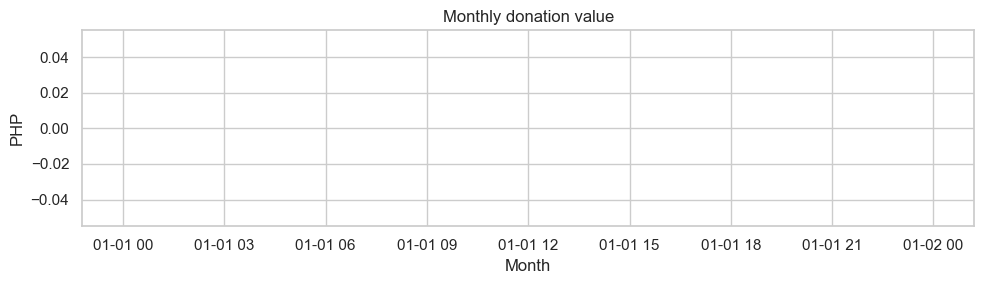

,month,total_value_php,n_donations


In [1]:
# ============================================================================
# Campaign effectiveness — Part 1: Load donations and plot monthly totals
# ============================================================================
# Notebook code cell overview — see inline comments below.
#
# Connects to SQLite (hiraya.db) and reads the donations fact table.
# Parses donation_date, builds value_php from amount with fallback to estimated_value.
# Aggregates to calendar month: total PHP raised and count of donations.
# The line chart is exploratory (EDA): shows seasonality and campaign mix over time.
# Downstream cells reuse `donations` and `monthly`; run this cell before modeling.
#
from __future__ import annotations

import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

sns.set_theme(style="whitegrid", context="notebook")

ROOT = Path("..").resolve()
DB_PATH = ROOT / "Data" / "hiraya.db"

with sqlite3.connect(DB_PATH) as conn:
    donations = pd.read_sql_query('SELECT * FROM "donations"', conn)

if donations.empty:
    raise ValueError(
        f'Table "donations" is empty in {DB_PATH}. '
        "Run db/sqlite/load_csv_to_sqlite.py to load CSV data into the database."
    )

donations["donation_date"] = pd.to_datetime(donations["donation_date"], errors="coerce")

# Use monetary amount when available else estimated_value
val = donations["amount"].fillna(donations["estimated_value"]).fillna(0.0)
donations["value_php"] = val

donations["month"] = donations["donation_date"].dt.to_period("M").dt.to_timestamp()

monthly = donations.groupby(["month"], as_index=False).agg(total_value_php=("value_php", "sum"), n_donations=("donation_id", "count"))

n_dated = donations["donation_date"].notna().sum()
if monthly.empty:
    print(
        f"WARNING: monthly aggregate is empty ({len(donations)} donation rows, "
        f"{n_dated} with parseable donation_date). "
        "Cell 2+ need valid dates across at least 2 months."
    )
else:
    print(f"Donations with valid month: {n_dated} rows | {len(monthly)} distinct months in panel.")

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(monthly["month"], monthly["total_value_php"], marker="o", ms=3)
ax.set_title("Monthly donation value")
ax.set_xlabel("Month")
ax.set_ylabel("PHP")
plt.tight_layout()
plt.show()

monthly.tail()

In [2]:
# ============================================================================
# Campaign effectiveness — Part 2: Explanatory regression (donation size)
# ============================================================================
# Notebook code cell overview — see inline comments below.
#
# Goal: describe association between campaign/channel/month and gift size — not causal inference.
# Ridge regression on one-hot encoded categories + scaled is_recurring reduces overfitting vs OLS.
# Out-of-time split: train on earlier months, test on later months — reduces optimistic leakage
#   that random train_test_split would cause when the same donors repeat across months.
# Coefficients on campaign_name_* are directional; interpretation depends on encoding baseline.
#
# Explanatory: donation-level regression with campaign controls

# Keep only donations with a known month
df = donations.dropna(subset=["month"]).copy()
df["campaign_name"] = df["campaign_name"].fillna("(none)")
df["channel_source"] = df["channel_source"].fillna("(unknown)")

# Time controls: month as categorical to reduce confounding by seasonality
cat_cols = ["campaign_name", "channel_source", "month"]
num_cols = ["is_recurring"]

X = df[cat_cols + num_cols]
y = df["value_php"].astype(float)

# Evaluation logic (Ch. 15): use an out-of-time split.
# Train on earlier months, test on later months to reduce optimistic leakage.
months = sorted(df["month"].dropna().unique())
if len(months) < 2:
    raise ValueError(
        "Out-of-time split needs at least 2 distinct calendar months with non-null donation_date. "
        f"Found {len(months)} month(s), {len(df)} donation row(s) after dropping null months. "
        f"Rebuild or fix {DB_PATH} (see db/sqlite/load_csv_to_sqlite.py)."
    )
cut = months[int(0.75 * len(months))]
train_mask = df["month"] < cut

y_train = y[train_mask]
y_test = y[~train_mask]
X_train = X[train_mask]
X_test = X[~train_mask]

pre = ColumnTransformer(
    [
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", Pipeline([("scaler", StandardScaler())]), num_cols),
    ]
)

model = Pipeline([("pre", pre), ("ridge", Ridge(alpha=5.0))])
model.fit(X_train, y_train)
pred = model.predict(X_test)
print("MAE (donation-level):", round(mean_absolute_error(y_test, pred), 2))

# Inspect top campaign coefficients (approximate associations)
# Note: coefficients depend on encoding; use this as a directional read.
enc = model.named_steps["pre"].named_transformers_["cat"]
feature_names = enc.get_feature_names_out(cat_cols)
coefs = model.named_steps["ridge"].coef_[: len(feature_names)]
coef_series = pd.Series(coefs, index=feature_names)

campaign_coefs = coef_series[coef_series.index.str.startswith("campaign_name_")].sort_values(ascending=False)
campaign_coefs.head(10)

IndexError: list index out of range

In [ ]:
# ============================================================================
# Campaign effectiveness — Part 3: Predictive forecast for next month's total giving
# ============================================================================
# Notebook code cell overview — see inline comments below.
#
# Uses only past monthly totals (lag1, lag2) to predict next month — a simple autoregressive baseline.
# Chronological split inside `train` (first 75% rows) keeps past-to-future ordering.
# Compare MAE here to business needs; this can feed a leadership dashboard (Phase 1 integration).
#
# Predictive: next-month total forecast using lags

m = monthly.sort_values("month").copy()
m["lag1"] = m["total_value_php"].shift(1)
m["lag2"] = m["total_value_php"].shift(2)
m["target_next"] = m["total_value_php"].shift(-1)

train = m.dropna(subset=["lag1", "target_next"]).copy()

if len(train) < 2:
    raise ValueError(
        "Predictive model needs at least 2 months of history after building lags. "
        f"Got len(train)={len(train)} (check monthly series and donation dates in {DB_PATH})."
    )

X = train[["lag1", "lag2"]].fillna(0)
y = train["target_next"]

# time split (chronological rows in `train`)
cut = max(1, int(0.75 * len(train)))
if cut >= len(train):
    cut = len(train) - 1
X_train, X_test = X.iloc[:cut], X.iloc[cut:]
y_train, y_test = y.iloc[:cut], y.iloc[cut:]

ridge = Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=1.0))])
ridge.fit(X_train, y_train)
pred = ridge.predict(X_test)
print("Next-month forecast MAE:", round(mean_absolute_error(y_test, pred), 2))

pd.DataFrame({"month": train["month"].iloc[cut:], "y_true": y_test.values, "y_pred": pred})

Next-month forecast MAE: 4476.86


,month,y_true,y_pred
28,2025-05-01,5320.31,7146.300675
29,2025-06-01,13673.05,7296.945034
30,2025-07-01,13191.88,7783.793592
31,2025-08-01,4588.70,9010.395304
32,2025-09-01,12419.56,7068.480331
33,2025-10-01,13490.65,5817.347495
34,2025-11-01,11071.80,8975.878229
35,2025-12-01,3942.52,7395.680929
36,2026-01-01,4457.14,6774.421929
37,2026-02-01,342.96,6188.909270


## 5. Causal and relationship analysis

Campaign coefficients from the explanatory model are **associations** conditional on month and channel.

- Campaigns may be run during special times (seasonality) or with extra spend (unobserved confounders).
- A “high coefficient” campaign is not guaranteed to *cause* higher giving; it may reflect targeting, donor composition, or marketing effort.

## 6. Deployment notes

- Add an internal dashboard showing campaign performance summaries:
  - donation totals by campaign
  - model-based “above baseline” estimate with caveats
  - forecast next month total donations
- Use as a planning tool for staffing and outreach timing.